# SQ3: SHAP Analysis Across Structural Contexts
Does the predictive contribution of mobility attitudes vary across predefined structural contexts?

Contexts examined:
- Urban vs Rural — spatial context (`UrbRur`)
- Work / mixed / leisure — trip purpose context (`TripPurpose`)
- Low vs high PT frequency — service availability context (median split of `frequency`)
- Employment status — socioeconomic context (`OccupStat`)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import shap

from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer

/opt/anaconda3/envs/Python/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Load Dataset

In [2]:
from pathlib import Path

filename = "ModeChoiceOptima_cleaned.csv"
base_path = Path("/Users/ecemturkay/Desktop/TIL/9. ME44312 - Machine Learning for Transport and Multi-Machine Systems/3. Project/Codes")  # put your own path

paths = list(base_path.rglob(filename))
df = pd.read_csv(paths[0])
print(df.shape)
df.head()

(1871, 117)


,ID,DestAct,NbTransf,TimePT,WalkingTimePT,WaitingTimePT,CostPT,CostCar,TimeCar,NbHousehold,...,FreqTripHouseh,Region,distance_km,Choice,InVehicleTime,ModeToSchool,ReportedDuration,CoderegionCAR,age,Weight
0,10350017,2.0,4,85,23,10,12.4,3.17,32,2.0,...,4.0,1,30.0,1,52.0,3.0,255.0,1,27.0,0.000379
1,10350075,1.0,3,107,21,31,24.0,2.36,23,2.0,...,1.0,1,25.0,1,55.0,4.0,30.0,1,63.0,0.000368
2,10350085,1.0,5,190,116,18,10.8,1.16,14,3.0,...,3.0,1,12.5,1,56.0,4.0,20.0,1,57.0,0.000409
3,10350086,1.0,4,116,38,29,9.6,1.89,20,3.0,...,3.0,1,19.0,1,49.0,4.0,30.0,1,58.0,0.000368
4,10350100,4.0,1,20,1,5,3.0,1.14,9,1.0,...,1.0,1,13.0,1,14.0,4.0,10.0,1,80.0,0.000202


## 2. Define Features & Train SQ3 Model

In [3]:
# Mobility scales
df['PT_attitude'] = df[['Mobil09','Mobil19','Mobil20','Mobil23','Mobil24']].replace([-1,-2], np.nan).mean(axis=1)
df['Car_attitude'] = df[['Mobil12','Mobil13','Mobil14']].replace([-1,-2], np.nan).mean(axis=1)
df['PT_barrier'] = df[['Mobil08','Mobil10','Mobil11','Mobil17','Mobil18']].replace([-1,-2], np.nan).mean(axis=1)

In [4]:
# Features (same as SQ2)
baseline_features = ["age", "Gender", "Income", "Education", "NbCar", "CarAvail", 
                     "NbHousehold", "NbChild", "NbTrajects", "TripPurpose", "distance_km", "OccupStat", "UrbRur"]

struct_features = ["TimePT", "TimeCar", "CostPT", "CostCar", "frequency", "ClassifCodeLine"]

mobility_features = ["PT_attitude", "Car_attitude", "PT_barrier"]

all_features = baseline_features + struct_features + mobility_features

categorical_features = [
    "Gender", "TripPurpose", "CarAvail", "OccupStat", "UrbRur"
]

numerical_features = [
    "age", "Income", "Education", "NbCar", "NbHousehold", "NbChild",
    "NbTrajects", "distance_km", "TimePT", "TimeCar", "CostPT", "CostCar", "frequency", "ClassifCodeLine",
    "PT_attitude", "Car_attitude", "PT_barrier"
]

X = df[all_features]
y = df["Choice"]

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Also keep context columns aligned with test set
context_cols = ["UrbRur", "TripPurpose", "frequency", "OccupStat"]
df_context = df[context_cols]
_, df_context_test = train_test_split(
    df_context, test_size=0.2, random_state=42, stratify=y
)
df_context_test = df_context_test.reset_index(drop=True)

print("Train size:", X_train.shape[0])
print("Test size:", X_test.shape[0])

Train size: 1496
Test size: 375


In [5]:
# Preprocessor
numeric_transformer = Pipeline([("imputer", SimpleImputer(strategy="median"))])
categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])
preprocessor = ColumnTransformer([
    ("num", numeric_transformer, numerical_features),
    ("cat", categorical_transformer, categorical_features)
])

# Model (same hyperparameters as SQ1)
rf_model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(
        n_estimators=200, max_depth=None, min_samples_leaf=2,
        max_features="sqrt", criterion="gini", bootstrap=True,
        class_weight="balanced", random_state=42, n_jobs=-1
    ))
])

rf_model.fit(X_train, y_train)
print("Model trained.")

Model trained.


In [6]:
y_pred = rf_model.predict(X_test)
from sklearn.metrics import accuracy_score, f1_score, classification_report

print("=== SQ3 Model (SQ2 + Mobility Scales) ===")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("F1 (weighted):", f1_score(y_test, y_pred, average="weighted"))
print(classification_report(y_test, y_pred))

=== SQ3 Model (SQ2 + Mobility Scales) ===
Accuracy: 0.832
F1 (weighted): 0.8272153812701757
              precision    recall  f1-score   support

           0       0.79      0.71      0.75       105
           1       0.86      0.91      0.88       247
           2       0.69      0.48      0.56        23

    accuracy                           0.83       375
   macro avg       0.78      0.70      0.73       375
weighted avg       0.83      0.83      0.83       375



## 3. Compute SHAP Values

In [7]:
# Transform test set with preprocessor
X_test_transformed = rf_model.named_steps["preprocessor"].transform(X_test)

# Get feature names after preprocessing
num_feature_names = numerical_features
cat_feature_names = rf_model.named_steps["preprocessor"] \
    .named_transformers_["cat"]["onehot"].get_feature_names_out(categorical_features).tolist()
all_feature_names = num_feature_names + cat_feature_names

# SHAP TreeExplainer
explainer = shap.TreeExplainer(rf_model.named_steps["classifier"])
shap_values = explainer.shap_values(X_test_transformed)  # shape: (n_classes, n_samples, n_features)

print("SHAP values computed.")
print("Number of classes:", len(shap_values))
print("Shape per class:", shap_values[0].shape)

SHAP values computed.
Number of classes: 375
Shape per class: (36, 3)


In [8]:
# shap_values shape: (n_samples, n_features, n_classes)
# Mean absolute SHAP across all classes
shap_abs_mean = np.mean(np.abs(shap_values), axis=2)  # (n_samples, n_features)

# Build a DataFrame for easier analysis
shap_df = pd.DataFrame(shap_abs_mean, columns=all_feature_names)
shap_df = shap_df.reset_index(drop=True)

print("SHAP DataFrame shape:", shap_df.shape)
shap_df.head()

SHAP DataFrame shape: (375, 36)


,age,Income,Education,NbCar,NbHousehold,NbChild,NbTrajects,distance_km,TimePT,TimeCar,...,OccupStat_2.0,OccupStat_3.0,OccupStat_4.0,OccupStat_5.0,OccupStat_6.0,OccupStat_7.0,OccupStat_8.0,OccupStat_9.0,UrbRur_1.0,UrbRur_2.0
0,0.014367,0.007050,0.007219,0.024855,0.005564,0.024182,0.003149,0.054453,0.035130,0.029432,...,0.004592,0.000026,0.000115,0.000018,0.000654,0.000002,0.003417,0.000460,0.002210,0.002254
1,0.008995,0.001522,0.005422,0.034479,0.003508,0.002244,0.007280,0.057866,0.033508,0.031534,...,0.003974,0.000005,0.000017,0.000019,0.000078,0.000004,0.002894,0.001141,0.000928,0.002446
2,0.005987,0.004598,0.005147,0.030209,0.007074,0.000561,0.006773,0.057517,0.030220,0.034701,...,0.003076,0.000029,0.000008,0.000019,0.000426,0.000002,0.002849,0.001368,0.002442,0.003404
3,0.006834,0.004100,0.007360,0.033469,0.002805,0.001742,0.006735,0.058842,0.052644,0.062067,...,0.003230,0.000012,0.000013,0.000019,0.000472,0.000002,0.002233,0.001743,0.000553,0.001739
4,0.006091,0.005993,0.008808,0.033177,0.002319,0.001019,0.010450,0.053489,0.054428,0.061623,...,0.003316,0.000012,0.000009,0.000020,0.000496,0.000002,0.002055,0.002064,0.000353,0.001391


In [12]:
# Signed SHAP per class
# class 0 = PT, class 1 = Car, class 2 = Soft
class_names = ["PT", "Car", "Soft"]
shap_signed_car = pd.DataFrame(shap_values[:, :, 1], columns=all_feature_names) 
shap_signed_pt = pd.DataFrame(shap_values[:, :, 0], columns=all_feature_names)   
shap_signed_car = shap_signed_car.reset_index(drop=True)
shap_signed_pt = shap_signed_pt.reset_index(drop=True)

## 4. Global SHAP Summary — Mobility Features

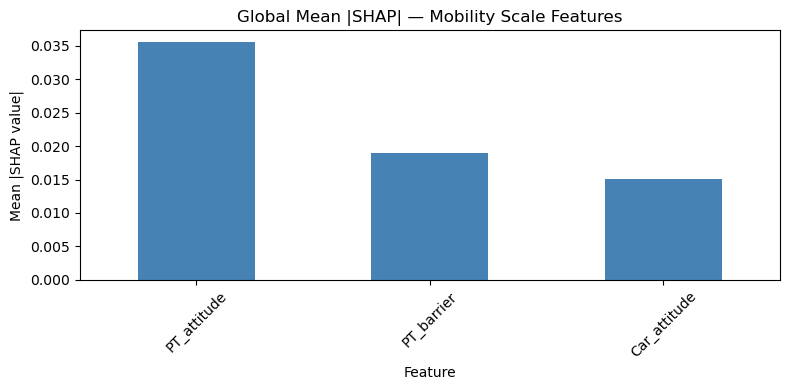

PT_attitude     0.035548
PT_barrier      0.018951
Car_attitude    0.015029
dtype: float64


In [13]:
# Global mean absolute SHAP for env features
mobility_features_scales = ["PT_attitude", "Car_attitude", "PT_barrier"]
global_mobility_shap = shap_df[mobility_features_scales].mean().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8, 4))
global_mobility_shap.plot(kind="bar", ax=ax, color="steelblue")
ax.set_title("Global Mean |SHAP| — Mobility Scale Features")
ax.set_ylabel("Mean |SHAP value|")
ax.set_xlabel("Feature")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("shap_global_mobility.png", dpi=150)
plt.show()
print(global_mobility_shap)

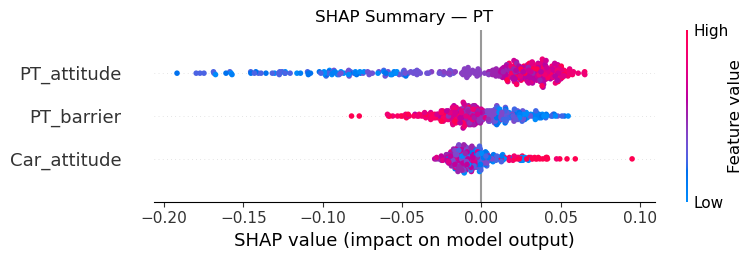

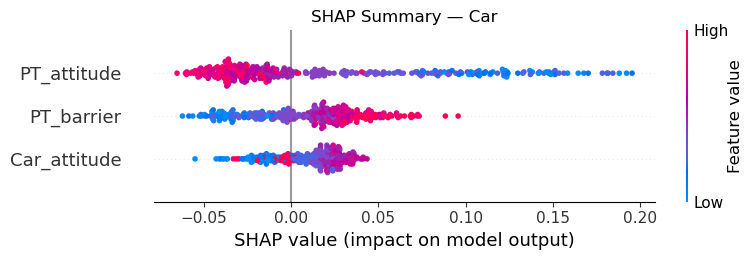

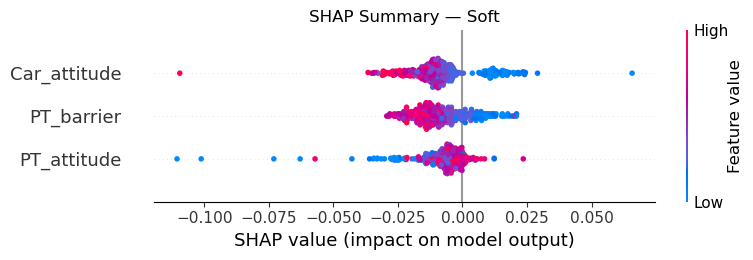

In [14]:
# Signed SHAP - Beeswarm plot per class
mobility_idx = [all_feature_names.index(f) for f in ["PT_attitude", "Car_attitude", "PT_barrier"]]

for i, class_name in enumerate(class_names):
    plt.figure()
    shap.summary_plot(
        shap_values[:, mobility_idx, i], 
        X_test_transformed[:, mobility_idx], 
        feature_names=["PT_attitude", "Car_attitude", "PT_barrier"],
        show=False
    )
    plt.title(f"SHAP Summary — {class_name}")
    plt.tight_layout()
    plt.savefig(f"shap_signed_{class_name}.png", dpi=150)
    plt.show()

## 5. Context Analysis

For each context, we split the test set into subgroups and compare the mean |SHAP| of mobility features.

In [15]:
def plot_shap_by_context(shap_df, context_series, context_name, group_labels, features, figsize=(10, 5)):
    """Compare mean |SHAP| of given features across two context groups."""
    groups = context_series.unique()
    results = {}
    for g, label in zip(sorted(groups), group_labels):
        mask = context_series == g
        results[label] = shap_df.loc[mask, features].mean()
    
    result_df = pd.DataFrame(results)
    
    fig, ax = plt.subplots(figsize=figsize)
    result_df.plot(kind="bar", ax=ax, colormap="Set2")
    ax.set_title(f"Mean |SHAP| of Mobility Features\nContext: {context_name}")
    ax.set_ylabel("Mean |SHAP value|")
    ax.set_xlabel("Feature")
    plt.xticks(rotation=45)
    plt.legend(title=context_name, bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout(rect=[0, 0, 0.85, 1])
    plt.savefig(f"shap_context_{context_name.replace(' ', '_')}.png", dpi=150)
    plt.show()
    
    return result_df

### 5.1 Urban vs Rural

In [16]:
# Check UrbRur values
print("UrbRur unique values:", df_context_test["UrbRur"].unique())
print(df_context_test["UrbRur"].value_counts())

UrbRur unique values: [1 2]
UrbRur
2    192
1    183
Name: count, dtype: int64


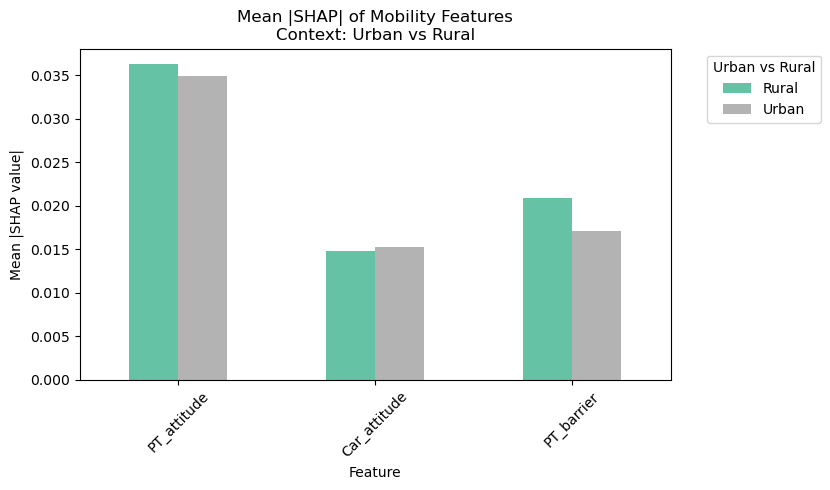

                 Rural     Urban
PT_attitude   0.036211  0.034916
Car_attitude  0.014841  0.015207
PT_barrier    0.020862  0.017130


In [17]:
urbrur_result = plot_shap_by_context(
    shap_df,
    context_series=df_context_test["UrbRur"].reset_index(drop=True),
    context_name="Urban vs Rural",
    group_labels=["Rural", "Urban"],  # adjust if needed based on encoding
    features=mobility_features
)
print(urbrur_result)

### 5.2 Trip Purpose

In [18]:
print("TripPurpose unique values:", df_context_test["TripPurpose"].unique())
print(df_context_test["TripPurpose"].value_counts())

TripPurpose unique values: [1. 3. 2.]
TripPurpose
3.0    190
1.0    136
2.0     49
Name: count, dtype: int64


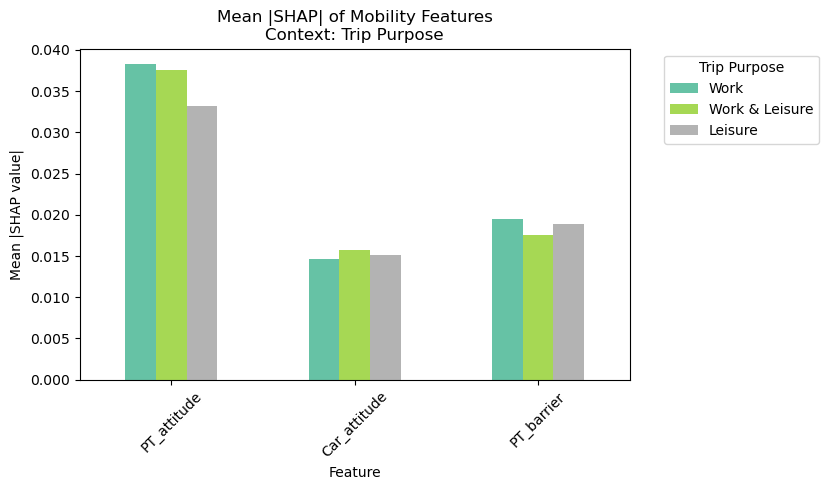

                  Work  Work & Leisure   Leisure
PT_attitude   0.038216        0.037501  0.033135
Car_attitude  0.014607        0.015709  0.015156
PT_barrier    0.019516        0.017579  0.018902


In [19]:
trippurp_result = plot_shap_by_context(
    shap_df,
    context_series=df_context_test["TripPurpose"].reset_index(drop=True),
    context_name="Trip Purpose",
    group_labels=["Work", "Work & Leisure", "Leisure"],  # adjust based on encoding
    features=mobility_features
)
print(trippurp_result)

### 5.3 Frequency

In [20]:
frequency_group = df_context_test["frequency"].reset_index(drop=True)
print(frequency_group.value_counts())

frequency
4    150
2     86
3     83
1     56
Name: count, dtype: int64


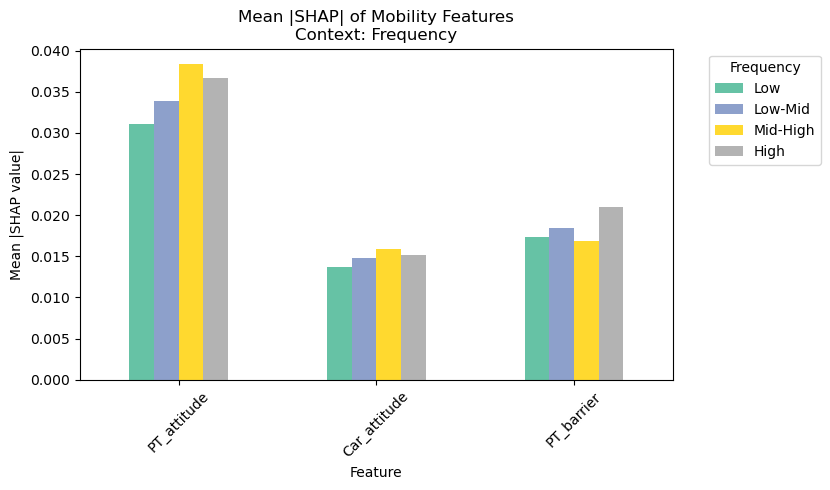

                   Low   Low-Mid  Mid-High      High
PT_attitude   0.031067  0.033900  0.038319  0.036632
Car_attitude  0.013645  0.014753  0.015912  0.015215
PT_barrier    0.017346  0.018501  0.016855  0.020969


In [21]:
frequency_result = plot_shap_by_context(
    shap_df,
    context_series=frequency_group,
    context_name="Frequency",
# 1 = Low frequency (<12 pairs/day)
# 2 = Low-middle frequency (13-20 pairs/day)
# 3 = Middle-high frequency (21-30 pairs/day)
# 4 = High frequency (>30 pairs/day)
    group_labels=["Low", "Low-Mid", "Mid-High", "High"],
    features=mobility_features
)
print(frequency_result)

### 5.4 OccupStat

In [22]:
occup_group = df_context_test["OccupStat"].reset_index(drop=True)
print(occup_group.value_counts())

OccupStat
1.0    189
2.0     85
9.0     53
8.0     20
6.0     17
3.0      6
5.0      2
4.0      2
7.0      1
Name: count, dtype: int64


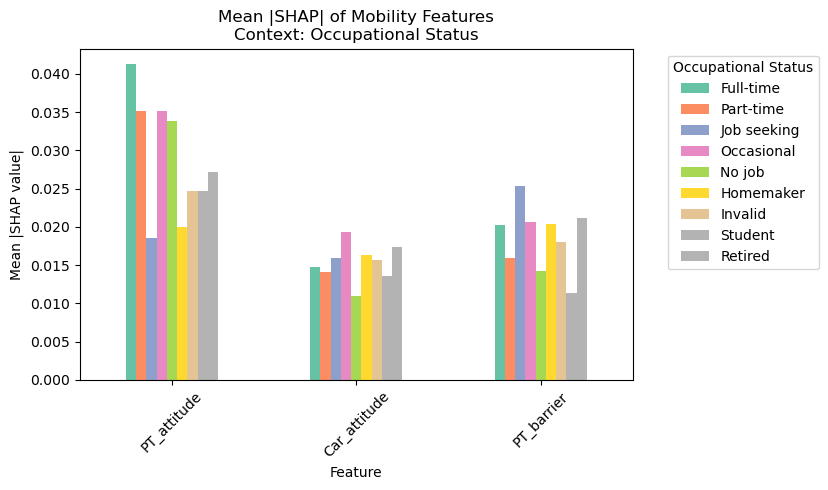

              Full-time  Part-time  Job seeking  Occasional    No job  \
PT_attitude    0.041243   0.035204     0.018481    0.035126  0.033847   
Car_attitude   0.014812   0.014048     0.015985    0.019290  0.010891   
PT_barrier     0.020193   0.015952     0.025329    0.020593  0.014284   

              Homemaker   Invalid   Student   Retired  
PT_attitude    0.019954  0.024661  0.024670  0.027117  
Car_attitude   0.016293  0.015687  0.013617  0.017375  
PT_barrier     0.020407  0.017997  0.011373  0.021136  


In [23]:
occup_result = plot_shap_by_context(
    shap_df,
    context_series=occup_group,
    context_name="Occupational Status",
    group_labels=["Full-time", "Part-time", "Job seeking", "Occasional", 
                  "No job", "Homemaker", "Invalid", "Student", "Retired"],
    features=mobility_features
)
print(occup_result)

## 6. Summary Heatmap — All Contexts

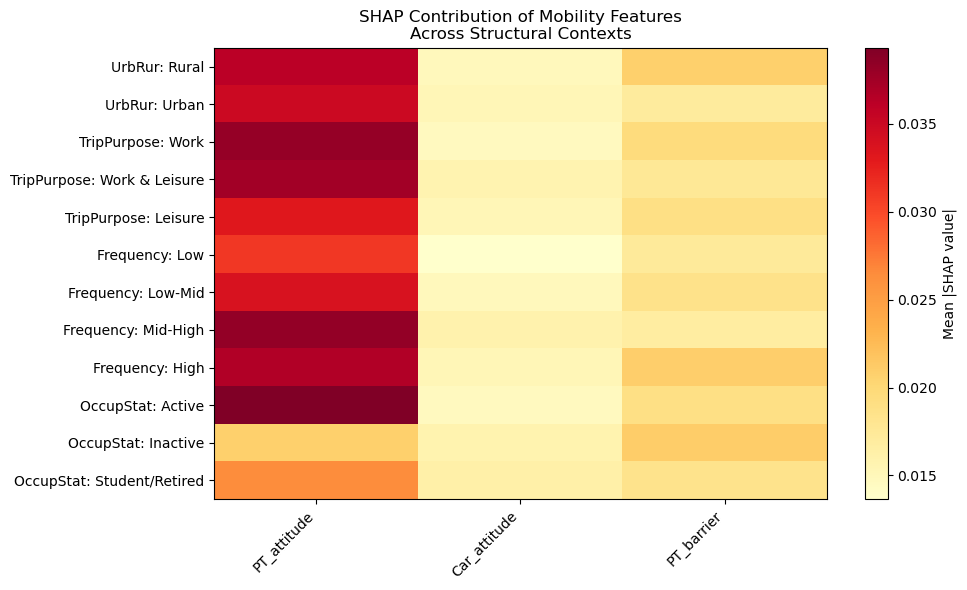

                             PT_attitude  Car_attitude  PT_barrier
UrbRur: Rural                     0.0362        0.0148      0.0209
UrbRur: Urban                     0.0349        0.0152      0.0171
TripPurpose: Work                 0.0382        0.0146      0.0195
TripPurpose: Work & Leisure       0.0375        0.0157      0.0176
TripPurpose: Leisure              0.0331        0.0152      0.0189
Frequency: Low                    0.0311        0.0136      0.0173
Frequency: Low-Mid                0.0339        0.0148      0.0185
Frequency: Mid-High               0.0383        0.0159      0.0169
Frequency: High                   0.0366        0.0152      0.0210
OccupStat: Active                 0.0393        0.0146      0.0189
OccupStat: Inactive               0.0209        0.0158      0.0210
OccupStat: Student/Retired        0.0264        0.0163      0.0185


In [24]:
# Build summary table: mean |SHAP| per env feature per context group
summary_rows = []

# Urban vs Rural
for g, label in zip(sorted(df_context_test["UrbRur"].unique()), ["Rural", "Urban"]):
    mask = df_context_test["UrbRur"].reset_index(drop=True) == g
    row = shap_df.loc[mask, mobility_features].mean()
    row.name = f"UrbRur: {label}"
    summary_rows.append(row)

# Trip Purpose
for g, label in zip([1,2,3], ["Work", "Work & Leisure", "Leisure"]):
    mask = df_context_test["TripPurpose"].reset_index(drop=True) == g
    row = shap_df.loc[mask, mobility_features].mean()
    row.name = f"TripPurpose: {label}"
    summary_rows.append(row)

# Frequency
for g, label in zip([1,2,3,4], ["Low", "Low-Mid", "Mid-High", "High"]):
    mask = df_context_test["frequency"].reset_index(drop=True) == g
    row = shap_df.loc[mask, mobility_features].mean()
    row.name = f"Frequency: {label}"
    summary_rows.append(row)

# OccupStat (basitleştirilmiş)
occup_map = {1:"Active", 2:"Active", 4:"Active",
             3:"Inactive", 5:"Inactive", 6:"Inactive", 7:"Inactive",
             8:"Student/Retired", 9:"Student/Retired"}
occup_simplified = df_context_test["OccupStat"].reset_index(drop=True).map(occup_map)
for label in ["Active", "Inactive", "Student/Retired"]:
    mask = occup_simplified == label
    row = shap_df.loc[mask, mobility_features].mean()
    row.name = f"OccupStat: {label}"
    summary_rows.append(row)

summary_df = pd.DataFrame(summary_rows)

fig, ax = plt.subplots(figsize=(10, 6))
im = ax.imshow(summary_df.values, aspect="auto", cmap="YlOrRd")
plt.colorbar(im, ax=ax, label="Mean |SHAP value|")
ax.set_xticks(range(len(mobility_features)))
ax.set_xticklabels(mobility_features, rotation=45, ha="right")
ax.set_yticks(range(len(summary_df)))
ax.set_yticklabels(summary_df.index)
ax.set_title("SHAP Contribution of Mobility Features\nAcross Structural Contexts")
plt.tight_layout()
plt.savefig("shap_heatmap_contexts.png", dpi=150)
plt.show()

print(summary_df.round(4))